In [32]:
import sys
!{sys.executable} -m pip install pandas

import pandas as pd

trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

print(trades.shape)
print(sentiment.shape)

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


(211224, 16)
(2644, 4)


In [33]:
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(" ", "_")

In [34]:
# Convert timestamps
trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)
print(trades['timestamp_ist'].head())
trades[trades['timestamp_ist'].isna()]
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract date only
trades['date'] = trades['timestamp_ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: timestamp_ist, dtype: datetime64[us]


In [35]:
print(trades.isnull().sum())
print(sentiment.isnull().sum())

# Drop rows where PnL missing
trades = trades.dropna(subset=['closed_pnl'])

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [36]:
merged.rename(columns={'classification': 'value_classification'}, inplace=True)

Feature Engineering

In [37]:
daily = merged.groupby(['account','date','value_classification']).agg({
    'closed_pnl': 'sum',
    'size_usd': 'mean',
    'trade_id': 'count',
    'win': 'mean'
}).reset_index()


daily.rename(columns={
    'trade_id': 'num_trades',
    'size_usd': 'avg_trade_size',
    'win': 'win_rate'
}, inplace=True)

In [38]:
# Ensure consistent case
merged['side'] = merged['side'].str.lower()

long_short = merged.groupby(['date','side']).size().unstack(fill_value=0)

# Ensure both columns exist
for col in ['buy', 'sell']:
    if col not in long_short.columns:
        long_short[col] = 0

# Safe ratio
long_short['long_short_ratio'] = long_short['buy'] / long_short['sell'].replace(0, 1)

In [39]:
activity = merged.groupby('date')['trade_id'].count().reset_index()
activity.rename(columns={'trade_id':'total_trades'}, inplace=True)

In [40]:
print(daily.columns)

Index(['account', 'date', 'value_classification', 'closed_pnl',
       'avg_trade_size', 'num_trades', 'win_rate'],
      dtype='str')


In [42]:
daily.groupby('value_classification')['closed_pnl'].mean()
daily.groupby('value_classification')['win_rate'].mean()

summary = daily.groupby('value_classification').agg({
    'closed_pnl': ['mean', 'sum'],
    'win_rate': 'mean',
    'num_trades': 'mean'
}).reset_index()

print(summary)

  value_classification   closed_pnl                win_rate  num_trades
                               mean           sum      mean        mean
0         Extreme Fear  4619.439053  7.391102e+05  0.329659  133.750000
1        Extreme Greed  5161.922644  2.715171e+06  0.386387   76.030418
2                 Fear  5328.818161  3.357155e+06  0.364033   98.153968
3                Greed  3318.100730  2.150129e+06  0.343559   77.628086
4              Neutral  3438.618818  1.292921e+06  0.355414  100.228723


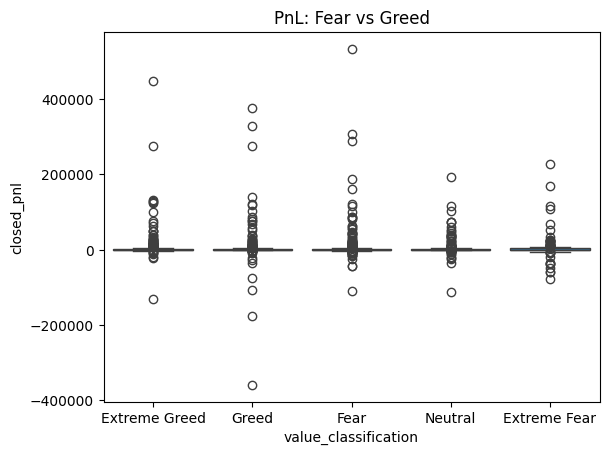

In [51]:
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='value_classification', y='closed_pnl', data=daily)
plt.title("PnL: Fear vs Greed")
plt.show()


<Axes: xlabel='value_classification', ylabel='num_trades'>

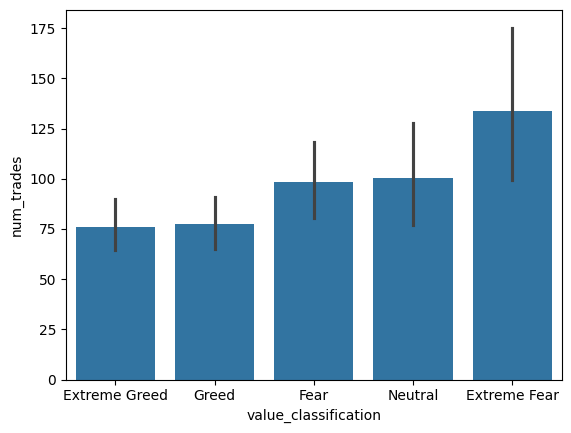

In [46]:
sns.barplot(x='value_classification', y='num_trades', data=daily)

<Axes: xlabel='value_classification', ylabel='avg_trade_size'>

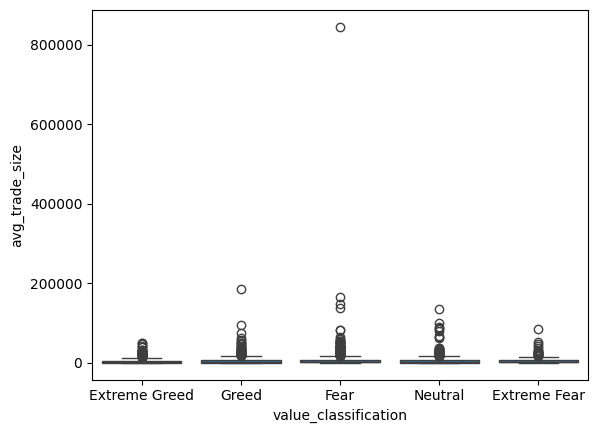

In [47]:
sns.boxplot(x='value_classification', y='avg_trade_size', data=daily)

In [50]:
daily['volume_group'] = daily['avg_trade_size'].apply(
    lambda x: 'High' if x > daily['avg_trade_size'].median() else 'Low'
)
daily['freq_group'] = daily['num_trades'].apply(
    lambda x: 'High' if x > 10 else 'Low'
)

consistency = daily.groupby('account')['win_rate'].mean().reset_index()

consistency['type'] = consistency['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.6 else 'Inconsistent'
)